## Task description:

The given file is call-center.xlsx. It contains data from a specific call center. The manager
needs to determine what time of day is the best solution.

Execute the input. Draw conclusions.

### 1. Libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns
from scipy.stats import kruskal
import scikit_posthocs as sp
from scipy.stats import norm

plt.colormaps()
cmap = plt.get_cmap("Pastel1")

### 2. Data

In [35]:

df = pd.read_excel(r'C:\Users\User\Desktop\MACHINE_LEARNING\Mentoring\Materiały_do_nauki\08_Test_po_statystyce\call_center.xlsx')
df = df[df['call_type'] == 'Outcoming']

### 3. Summary Statistics

In [36]:
df_desc = df.drop(['id','phone_num','staff_id'], axis = 1)
df_desc.describe()

,handle_time,Total_Client_Time,Abandon_Time
count,5179.000000,5179.000000,5179.0
mean,58.525005,58.525005,0.0
std,97.903391,97.903391,0.0
min,0.000000,0.000000,0.0
25%,9.000000,9.000000,0.0
50%,36.000000,36.000000,0.0
75%,64.000000,64.000000,0.0
max,1447.000000,1447.000000,0.0


In [37]:
# numerical variables
df_desc_numerical = df_desc.describe()
df_desc_numerical.loc['skewness'] = round(df_desc.skew(numeric_only = True),2)
df_desc_numerical.loc['kurtosis'] = round(df_desc.kurt(numeric_only = True),2)
df_desc_numerical

,handle_time,Total_Client_Time,Abandon_Time
count,5179.000000,5179.000000,5179.0
mean,58.525005,58.525005,0.0
std,97.903391,97.903391,0.0
min,0.000000,0.000000,0.0
25%,9.000000,9.000000,0.0
50%,36.000000,36.000000,0.0
75%,64.000000,64.000000,0.0
max,1447.000000,1447.000000,0.0
skewness,5.850000,5.850000,0.0
kurtosis,49.890000,49.890000,0.0


In [38]:
df['hour'] = df['start_time'].apply(lambda x: int(x.hour))
groups = df.groupby('hour')['handle_time '].apply(list)
groups

hour
8     [85, 47, 84, 54, 4, 4, 29, 34, 48, 78, 15, 2, ...
9     [2, 15, 32, 78, 2, 0, 2, 14, 19, 3, 20, 2, 87,...
10    [52, 2, 80, 201, 65, 4, 58, 14, 31, 0, 25, 60,...
11    [17, 25, 78, 6, 42, 75, 16, 2, 368, 45, 82, 67...
12    [10, 36, 2, 67, 90, 8, 2, 38, 140, 9, 57, 19, ...
13    [51, 7, 22, 187, 8, 29, 44, 3, 7, 3, 48, 8, 12...
14    [36, 96, 129, 142, 4, 2, 4, 49, 27, 12, 65, 4,...
15    [5, 30, 63, 73, 56, 48, 67, 9, 22, 122, 621, 4...
16    [35, 14, 34, 33, 90, 31, 47, 591, 402, 21, 14,...
17    [2, 18, 21, 94, 20, 2, 586, 2, 10, 18, 25, 32,...
Name: handle_time , dtype: object

To determine the optimal time of day for making outbound calls, the following key performance indicators (KPIs) were defined:

* average handle time (avg handle time),
* number of calls (call volume),
* abandonment rate (abandon rate).

This approach allows for a balanced assessment of customer engagement, operational efficiency and accessibility throughout the day.

In [39]:
summary_per_hours = df.groupby('hour').agg(
    avg_handle_time=('handle_time ', 'mean'),
    calls=('handle_time ', 'count'),
    abandon_rate = ('abandon', lambda x: (x == 'Y').mean())
)

summary_per_hours = summary_per_hours.sort_values(
    ['avg_handle_time','calls','abandon_rate'],
    ascending = [False, False, False]
)


### 4. Hourly Analysis of Call Center Activity

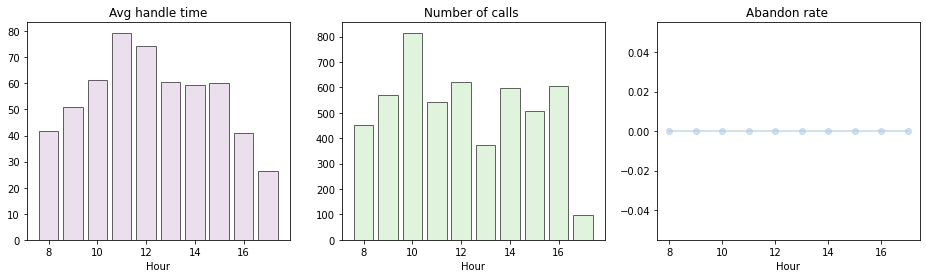

In [40]:
fig, ax = plt.subplots(1, 3, figsize = (16, 4))

ax[0].bar(summary_per_hours.index, summary_per_hours['avg_handle_time'], alpha = 0.6, edgecolor = 'black', color = cmap(0.4))
ax[0].set_title('Avg handle time')
ax[0].set_xlabel('Hour')

ax[1].bar(summary_per_hours.index, summary_per_hours['calls'], alpha=0.6, edgecolor='black', color = cmap(0.3))
ax[1].set_title("Number of calls ")
ax[1].set_xlabel("Hour")


ax[2].plot(summary_per_hours.index, summary_per_hours['abandon_rate'], marker = 'o',linewidth=2, alpha = 0.6, color = cmap(0.2))
ax[2].set_title("Abandon rate ")
ax[2].set_xlabel("Hour");

Based on the average handling time, it can be assumed that the most efficient customer interactions occurred between 10:00 and 12:00. In the afternoon hours, particularly after 16:00, a decrease in call duration is observed, which may indicate lower customer engagement. 

In [41]:
summary_per_hours['efficiency'] = summary_per_hours['avg_handle_time'] * summary_per_hours['calls']
summary_per_hours['efficiency_norm'] = (summary_per_hours['efficiency'] - summary_per_hours['efficiency'].mean()) / summary_per_hours['efficiency'].std()
summary_per_hours


,avg_handle_time,calls,abandon_rate,efficiency,efficiency_norm
hour,,,,,
11,79.464088,543,0.0,43149.0,0.903919
12,74.219904,623,0.0,46239.0,1.121470
10,61.138650,815,0.0,49828.0,1.374152
13,60.591398,372,0.0,22540.0,-0.547052
15,60.312253,506,0.0,30518.0,0.014637
14,59.328859,596,0.0,35360.0,0.355537
9,51.107206,569,0.0,29080.0,-0.086605
8,41.940397,453,0.0,18999.0,-0.796355
16,40.995050,606,0.0,24843.0,-0.384910


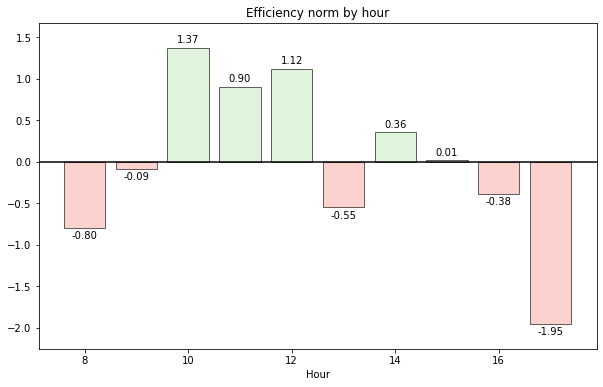

In [42]:
import matplotlib.pyplot as plt

colors = [cmap(0.1) if x < 0 else cmap(0.3) for x in summary_per_hours['efficiency_norm']]

plt.figure(figsize=(10,6))
bars = plt.bar(summary_per_hours.index, summary_per_hours['efficiency_norm'], alpha =0.6, edgecolor='black', color=colors)
plt.axhline(0, color='black')
plt.title("Efficiency norm by hour")
plt.xlabel('Hour')
plt.ylim(
    summary_per_hours['efficiency_norm'].min() - 0.3,
    summary_per_hours['efficiency_norm'].max() + 0.3
)
plt.bar_label(bars, fmt='%.2f', padding=3)

plt.show()

The efficiency_norm indicator represents a standardized version of efficiency, enabling comparison across hours relative to the overall mean of the analyzed period. Efficiency is defined as the product of the average call handling time (avg_handle_time) and the number of calls (calls), capturing the overall operational workload in each hour.

As shown in the chart, based on this metric, the most favorable hour for making calls is 10:00. However, confirming this hypothesis would require an analysis of call effectiveness or the application of statistical tests on individual-level data.

### 5. Checking the normality of handel time distribution

#### Histogram

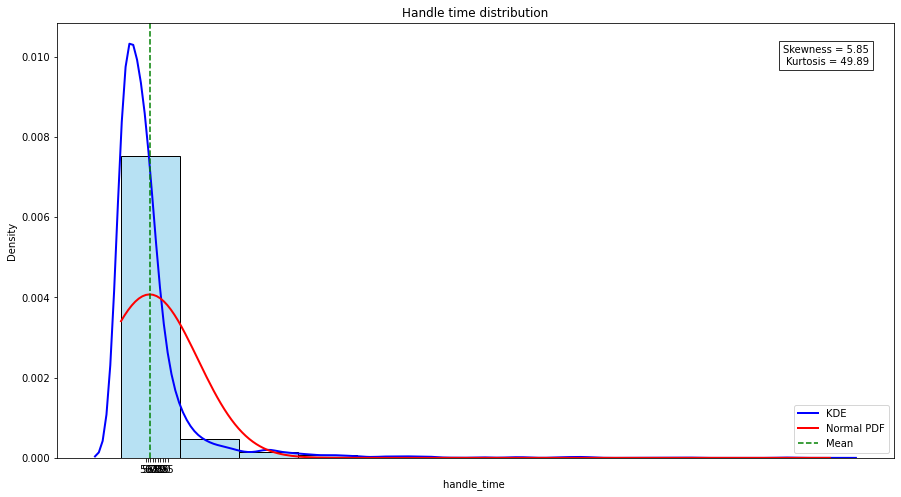

In [53]:
mu = df['handle_time '].mean()
sigma = df['handle_time '].std()

x = np.linspace(df['handle_time '].min(),
               df['handle_time '].max(), 200)

pdf = norm.pdf(x, mu, sigma)

skew_time = df['handle_time '].skew()
kurt_time = df['handle_time '].kurt()

fig, ax = plt.subplots(figsize = (15, 8 ))


sns.histplot(
    df['handle_time '],
    bins=12,
    stat='density',
    color='skyblue',
    edgecolor='black',
    alpha=0.6,
    ax=ax
)

sns.kdeplot(
    df['handle_time '],
    color='blue',
    lw=2,
    ax=ax,
    label='KDE'
)

ax.plot(x, pdf, color='red', lw=2, label='Normal PDF')
ax.axvline(mu, color='green', linestyle='--', label='Mean')

ax.text(
    0.97, 0.95,
    f'Skewness = {skew_time:.2f}\nKurtosis = {kurt_time:.2f}',
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8)
)
ax.set_xticks(range(50,100,5))
ax.legend(loc='lower right')
ax.set_title('Handle time distribution')
plt.show()

Handle time exhibits strong positive skewness (5.85) and extremely high kurtosis (49.89), indicating a non-normal distribution with a long right tail and numerous outliers. Most calls are completed quickly, while a small proportion of calls take considerably longer to resolve.

#### QQ plot

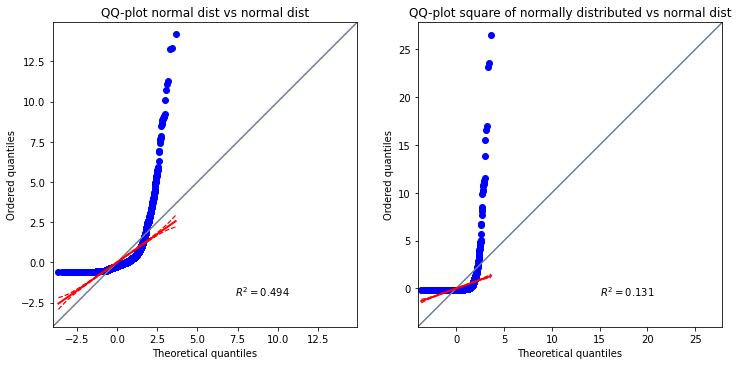

In [43]:
handle_time_n = df['handle_time ']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1 = pg.qqplot(handle_time_n, dist='norm', ax=ax1, confidence=0.95)
ax1.set_title('QQ-plot normal dist vs normal dist')
ax2 = pg.qqplot(handle_time_n**2, dist='norm', ax=ax2, confidence=0.95)
ax2.set_title('QQ-plot square of normally distributed vs normal dist')
plt.show()

The distribution of call handling time (handle_time) was examined using a Q–Q plot. The results indicate a significant deviation from the normal distribution, suggesting a positive skewness that is typical for operational call center data.

#### Boxplot

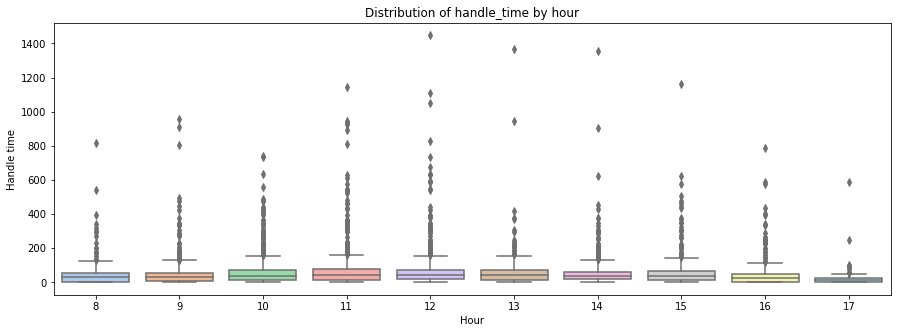

In [44]:
plt.figure(figsize = (15,5))


sns.boxplot(data = df, x = 'hour', y = 'handle_time ', palette='pastel')
plt.title('Distribution of handle_time by hour')
plt.xlabel('Hour')
plt.ylabel('Handle time')
plt.show()

### 5. Tests

#### Test Kruskal-Wallis

In [60]:
# H0: The distribution of handle time is the same across all hours.
# H1: At least one hour differs from the others.

alpha = 0.05

groups = [
    group['handle_time '].values
    for _, group in df.groupby('hour')
]

stat, p_value = kruskal(*groups)

print(f'Statistic = {stat:.4f}')
print(f'p-value = {p_value:.6f}')

if p_value < alpha:
    print('There are statistically significant differences between the hours.')
else:
    print('There are no statistically significant differences between the hours.')

Statistic = 191.7734
p-value = 0.000000
There are statistically significant differences between the hours.


The Kruskal–Wallis test indicates a statistically significant difference in handle_time across hours (H = 191.7734, p-value < 0.001). This means that at least one hour differs significantly from the others in terms of call handling time distribution.

In [61]:
dunn = sp.posthoc_dunn(
    df,
    val_col='handle_time ',
    group_col='hour',
    p_adjust='bonferroni'
)

print(dunn)

              8         9             10            11            12  \
8   1.000000e+00  1.000000  1.524054e-06  4.121719e-09  2.779302e-10   
9   1.000000e+00  1.000000  2.952348e-03  1.405417e-05  1.681623e-06   
10  1.524054e-06  0.002952  1.000000e+00  1.000000e+00  1.000000e+00   
11  4.121719e-09  0.000014  1.000000e+00  1.000000e+00  1.000000e+00   
12  2.779302e-10  0.000002  1.000000e+00  1.000000e+00  1.000000e+00   
13  5.755765e-05  0.020874  1.000000e+00  1.000000e+00  1.000000e+00   
14  3.736198e-05  0.025984  1.000000e+00  1.000000e+00  1.000000e+00   
15  1.573287e-04  0.065063  1.000000e+00  1.000000e+00  1.000000e+00   
16  1.000000e+00  0.135391  1.351759e-11  2.017259e-14  2.802550e-16   
17  1.723159e-03  0.000012  1.442527e-11  1.225851e-13  2.653498e-14   

              13            14            15            16            17  
8   5.755765e-05  3.736198e-05  1.573287e-04  1.000000e+00  1.723159e-03  
9   2.087376e-02  2.598378e-02  6.506345e-02  1.353912e-0

Post-hoc Dunn’s test revealed clear segmentation of hours into distinct performance groups. Mid-day hours (10:00–15:00) show no statistically significant differences in handle time, indicating stable operational performance. In contrast, early morning (08:00) and late afternoon hours (16:00–17:00) significantly differ from the rest of the day, exhibiting poorer performance in terms of call handling time.

In [63]:
hourly = (
    df.groupby('hour')
      .agg(
          median=('handle_time ', 'median'),
          p90=('handle_time ', lambda x: x.quantile(0.9)),
          calls=('handle_time ', 'count')
      )
      .sort_values('median')
)

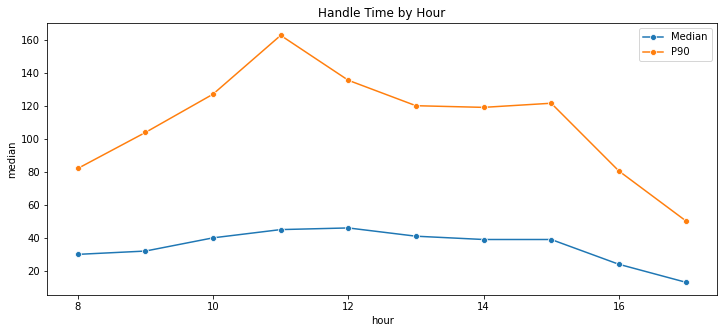

In [64]:
plt.figure(figsize=(12,5))

sns.lineplot(data=hourly, x='hour', y='median', marker='o', label='Median')
sns.lineplot(data=hourly, x='hour', y='p90', marker='o', label='P90')

plt.title('Handle Time by Hour')
plt.show()

In [67]:
df['segment'] = df['hour'].apply(lambda x:
    'peak' if x in range(10,16)
    else 'low' if x in [8,16,17]
    else 'mid'
)
df.groupby('segment')['handle_time '].agg(['median','mean','count'])

,median,mean,count
segment,,,
low,24.0,40.161905,1155
mid,32.0,51.107206,569
peak,41.0,65.885384,3455


Statistical testing (Kruskal–Wallis and Dunn’s post-hoc) confirmed significant differences in call handling time across hours. The analysis reveals a stable high-performance window between 10:00 and 15:00, where no statistically significant differences are observed and median handling times remain consistently low. In contrast, early morning (08:00) and late afternoon (16:00–17:00) show significantly worse performance, indicating suboptimal operational efficiency during these periods.